In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

## Convert Training Reward from a TensorBoard Scalar to CSV

In [2]:

def tensorboard_to_csv(log_dir, tag, csv_filename):
    """
    Export a TensorBoard scalar to CSV.

    Parameters
    ----------
    log_dir : str
        Path to the TensorBoard log directory (or event file).
    tag : str
        Name of the scalar to export.
    csv_filename : str
        Base filename for the output CSV (the tag name will be appended).

    Returns
    -------
    pd.DataFrame
        The exported scalar data (wall time, step, value).
    """

    # Load TensorBoard events
    ea = EventAccumulator(log_dir)
    ea.Reload()

    # Validate that the requested tag exists
    available_tags = ea.Tags()["scalars"]
    if tag not in available_tags:
        raise ValueError(
            f"Tag '{tag}' not found.\n"
            f"Available tags:\n{available_tags}"
        )

    events = ea.Scalars(tag)

    df = pd.DataFrame({
        "Wall time": [e.wall_time for e in events],
        "Step": [e.step for e in events],
        "Value": [e.value for e in events]
    })

    # Append tag to filename to avoid overwriting when exporting multiple tags
    full_csv_filename = csv_filename + "-" + tag+".csv"
    df.to_csv(full_csv_filename, index=False)

    print(f"Saved {len(df)} entries to {full_csv_filename}")

    return df

In [3]:
df = tensorboard_to_csv(
    log_dir="../../logs/train/DoubleDQN_OnRL",
    tag="AvgEpRew",
    csv_filename="train-DoubleDQN_OnRL"
)

Saved 4000 entries to train-DoubleDQN_OnRL-AvgEpRew.csv


## Plot Training Rewards for Stability Analysis

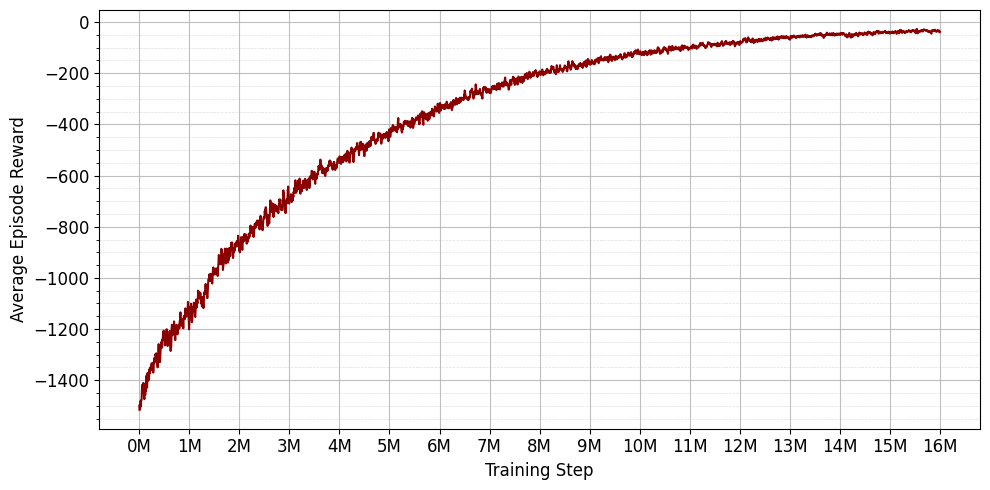

In [8]:
df = pd.read_csv('train-DoubleDQN_OnRL-AvgEpRew.csv') 

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Step'], df['Value'], color='#8B0000', linewidth=1.5)

ax.set_xlabel('Training Step',fontsize=12)
ax.set_ylabel('Average Episode Reward',fontsize=12)
# ax.set_title('Average Episode Reward vs Training Steps')

# X-axis: show 0M, 1M, ..., 16M
ax.xaxis.set_major_locator(MultipleLocator(1_000_000))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# Y-axis ticks
ax.yaxis.set_major_locator(MultipleLocator(200))
ax.yaxis.set_minor_locator(MultipleLocator(50))

# Grid
ax.grid(which='major', axis='y', linestyle='-', linewidth=0.8, alpha=0.8)
ax.grid(which='minor', axis='y', linestyle='--', linewidth=0.5, alpha=0.4)
ax.grid(which='major', axis='x', linestyle='-', linewidth=0.8, alpha=0.8)

plt.tight_layout()
plt.savefig('training_reward_curve.pdf', dpi=150, bbox_inches='tight')
plt.show()